In [12]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Jyoti\BITS\ML Assignment 2\Dry_Bean.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:\n", df['Class'].value_counts())


print("\nFeature Summary:\n")
print(df.describe())

Dataset Shape: (13611, 17)

First 5 rows:
     Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFact

In [13]:
# Step 2: Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Encode target labels (beans are categorical strings)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded sample:", y_encoded[:10])

# Scale features (important for kNN, Logistic Regression, etc.)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Encoded sample: [5 5 5 5 5 5 5 5 5 5]
Training set shape: (10888, 16)
Test set shape: (2723, 16)


In [39]:
# Step 3a: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import joblib, json

import os

# Ensure 'model' folder exists
os.makedirs("model", exist_ok=True)


results = []

# Train model
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# Multi-class AUC
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
y_pred_prob = log_reg.predict_proba(X_test)
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

# Append to results list
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MCC": mcc
})

# Save model
joblib.dump(log_reg, "model/logistic_regression.pkl")

# Save metrics
with open("model/logistic_regression_metrics.json", "w") as f:
    json.dump({
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }, f, indent=4)

Logistic Regression Results:
Accuracy: 0.9210
AUC: 0.9934
Precision: 0.9219
Recall: 0.9210
F1 Score: 0.9212
MCC: 0.9046


In [40]:
from sklearn.tree import DecisionTreeClassifier

# Train model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)
y_pred_prob = dt.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Decision Tree Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MCC": mcc
})

# Save model + metrics
os.makedirs("model", exist_ok=True)
joblib.dump(dt, "model/decision_tree.pkl")

with open("model/decision_tree_metrics.json", "w") as f:
    json.dump({
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }, f, indent=4)

Decision Tree Results:
Accuracy: 0.8920
AUC: 0.9334
Precision: 0.8917
Recall: 0.8920
F1 Score: 0.8916
MCC: 0.8696


In [41]:
from sklearn.neighbors import KNeighborsClassifier

# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)
y_pred_prob = knn.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("KNN Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

results.append({
    "Model": "KNN",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MCC": mcc
})

# Save model + metrics
os.makedirs("model", exist_ok=True)
joblib.dump(knn, "model/knn.pkl")

with open("model/knn_metrics.json", "w") as f:
    json.dump({
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }, f, indent=4)

KNN Results:
Accuracy: 0.9170
AUC: 0.9813
Precision: 0.9177
Recall: 0.9170
F1 Score: 0.9172
MCC: 0.8996


In [42]:
from sklearn.naive_bayes import GaussianNB

# Train model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predictions
y_pred = nb.predict(X_test)
y_pred_prob = nb.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Naive Bayes Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MCC": mcc
})

# Save model + metrics
os.makedirs("model", exist_ok=True)
joblib.dump(nb, "model/naive_bayes.pkl")

with open("model/naive_bayes_metrics.json", "w") as f:
    json.dump({
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }, f, indent=4)

Naive Bayes Results:
Accuracy: 0.8979
AUC: 0.9902
Precision: 0.9007
Recall: 0.8979
F1 Score: 0.8981
MCC: 0.8773


In [43]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

print("Random Forest Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MCC": mcc
})

# Save model + metrics
os.makedirs("model", exist_ok=True)
joblib.dump(rf, "model/random_forest.pkl")

with open("model/random_forest_metrics.json", "w") as f:
    json.dump({
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }, f, indent=4)

Random Forest Results:
Accuracy: 0.9207
AUC: 0.9914
Precision: 0.9209
Recall: 0.9207
F1 Score: 0.9207
MCC: 0.9041


In [44]:
from xgboost import XGBClassifier

# Train model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
y_pred_prob = xgb.predict_proba(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

# Multi-class AUC
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
auc = roc_auc_score(y_test_bin, y_pred_prob, average='weighted', multi_class='ovr')

# Print results
print("XGBoost Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

# Save results into the results list
results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy,
    "AUC": auc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "MCC": mcc
})

# Save model + metrics
os.makedirs("model", exist_ok=True)
joblib.dump(xgb, "model/xgboost.pkl")

with open("model/xgboost_metrics.json", "w") as f:
    json.dump({
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }, f, indent=4)

C:\Users\Jyoti\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:45:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
Accuracy: 0.9240
AUC: 0.9937
Precision: 0.9241
Recall: 0.9240
F1 Score: 0.9239
MCC: 0.9080


In [45]:
# Show all metrics side by side
pd.set_option("display.max_columns", None)   # ensures all columns are visible
pd.set_option("display.width", 1000)         # prevents wrapping

print("\nFinal Comparison Table:\n")
print(results_df)


Final Comparison Table:

                 Model  Accuracy       AUC  Precision    Recall  F1 Score       MCC
0  Logistic Regression  0.921043  0.993389   0.921850  0.921043  0.921233  0.904609
1        Decision Tree  0.892031  0.933376   0.891693  0.892031  0.891630  0.869569
2                  KNN  0.917003  0.981302   0.917728  0.917003  0.917153  0.899648
3          Naive Bayes  0.897907  0.990201   0.900702  0.897907  0.898075  0.877263
4        Random Forest  0.920676  0.991447   0.920858  0.920676  0.920650  0.904052


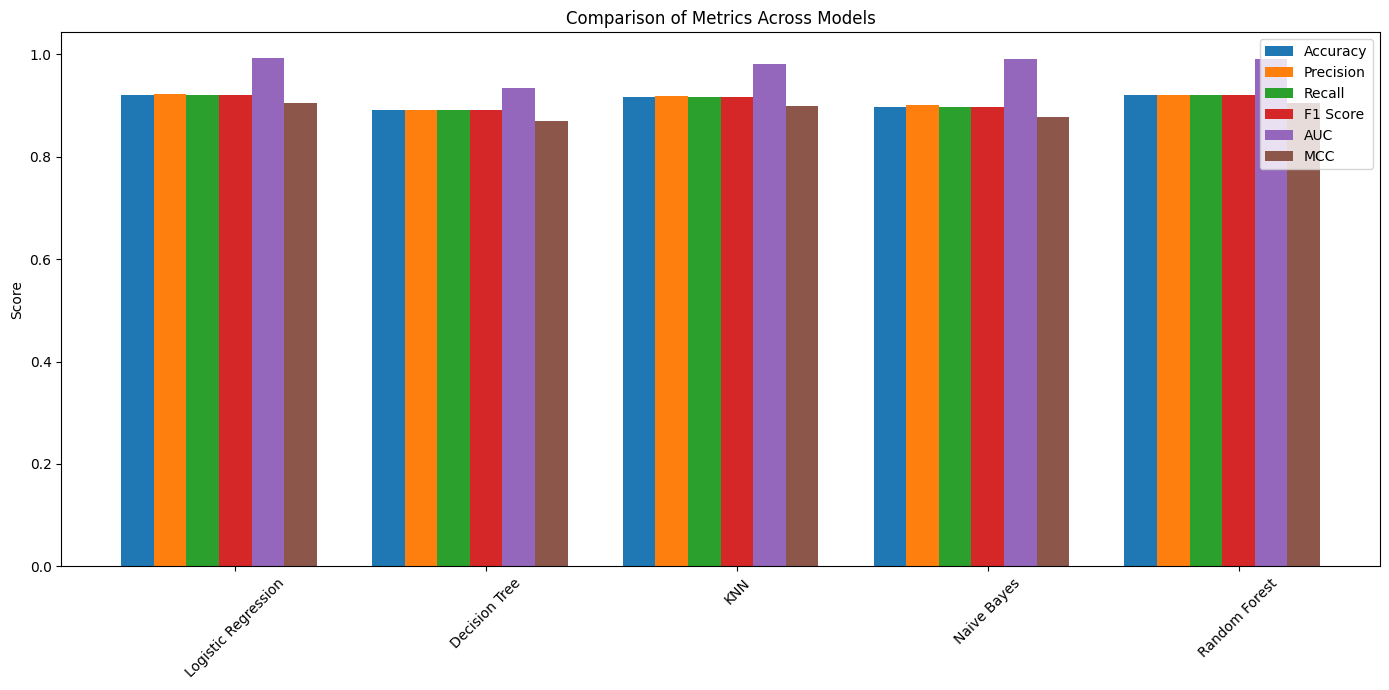

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC", "MCC"]

# Number of models
n_models = len(results_df["Model"])

# X positions for models
x = np.arange(n_models)

# Bar width
bar_width = 0.13

# Create grouped bar chart
plt.figure(figsize=(14,7))

for i, metric in enumerate(metrics):
    plt.bar(x + i*bar_width, results_df[metric], width=bar_width, label=metric)

plt.xticks(x + bar_width*len(metrics)/2, results_df["Model"], rotation=45)
plt.ylabel("Score")
plt.title("Comparison of Metrics Across Models")
plt.legend()
plt.tight_layout()
plt.show()